# 基于`transformer`的翻译模型

In [ ]:
import io
import re
import jieba
import tensorflow as tf
import time
import numpy as np
import matplotlib.pyplot as plt
import zhconv
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import FontManager
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from matplotlib.font_manager import FontProperties

2024-07-14 17:31:38.934329: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. 数据预处理

In [2]:
data_dir = 'cmn-eng/cmn_new.txt'

In [3]:
io.open(data_dir, encoding='utf-8').readlines()[:5]

['The kabedon scene in the drama made the fans very excited.\t电视剧里的壁咚场景让粉丝们很激动。\tCC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #891077 (Martha)\n',
 "Our plan ran into problems, now we're really screwed.\t我们的计划出了问题, 现在真的是BBQ了。\tCC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #891077 (Martha)\n",
 'The background music of this video is very nice.\t这段视频的bgm很好听。\tCC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #891077 (Martha)\n',
 'Whenever there is gossip, onlookers gather to watch.\t每当有八卦事件发生，吃瓜群众就会聚集观看。\tCC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #891077 (Martha)\n',
 "Everyone hurry up, let's go!\t大家快点，冲鸭！\tCC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #891077 (Martha)\n"]

In [4]:
# 英文处理
def preprocess_eng(w):
    w = w.lower().strip()

    # 在单词与跟在其后的标点符号之间插入一个空格
    w = re.sub(r"([?.!,¿])", r" \1 ", w)
    w = re.sub(r"[' ']+", " ", w)

    # 将所有字符替换为空格
    w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)

    w = w.rstrip().strip()

    # 加入开始和结束标记
    w = '<start> ' + w + ' <end>'
    return w

In [5]:
# 中文处理
def preprocess_zh(w):
    w = zhconv.convert(w, "zh-cn")
    w = ' '.join(jieba.cut(w))
    w = w.rstrip().strip()
    w = "<start> " + w + " <end>"
    return w

In [6]:
# 原始语料划分
def create_dataset(data_dir, num_examples):
    lines = io.open(data_dir, encoding='utf-8').read().strip().split('\n')
    eng, zh = [], []
    for line in lines[:num_examples]:
        word_pairs = line.split("\t")
        eng.append(preprocess_eng(word_pairs[0]))
        zh.append(preprocess_zh(word_pairs[1]))
    return [eng, zh]

In [7]:
eng, zh = create_dataset(data_dir, None)
print(eng[-1])
print(zh[-1])

Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
Loading model cost 0.629 seconds.
Prefix dict has been built successfully.


<start> i m so hungry , i really want to have a meal . <end>
<start> 太饿 了 ， 好想 恰饭 啊 。 <end>


In [8]:
# 文本向量化
def tokenize(lang):
    lang_tokenizer = tf.keras.preprocessing.text.Tokenizer(filters=' ')
    lang_tokenizer.fit_on_texts(lang)
    tensor = lang_tokenizer.texts_to_sequences(lang)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor,
                                                           padding="post")
    return tensor, lang_tokenizer

In [9]:
def load_dataset(data_dir, num_examples=None):
    eng, zh = create_dataset(data_dir, num_examples)
    zh_tensor, zh_tokenizer = tokenize(zh)
    eng_tensor, eng_tokenizer = tokenize(eng)
    return zh_tensor, zh_tokenizer, eng_tensor, eng_tokenizer

In [10]:
num_examples = None
zh_tensor, zh_tokenizer, eng_tensor, eng_tokenizer = load_dataset(data_dir, num_examples)

In [11]:
# 保存分词器
tokenizer_dir = 'H/save/zh2eng_transformer_tokenizer/'
zh_tokenizer_dir = tokenizer_dir + 'zh_tokenizer.json'
eng_tokenizer_dir = tokenizer_dir + 'eng_tokenizer.json'

tokenizer_json = zh_tokenizer.to_json()
with io.open(zh_tokenizer_dir, 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

tokenizer_json = eng_tokenizer.to_json()
with io.open(eng_tokenizer_dir, 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

In [12]:
print(zh_tensor.shape, eng_tensor.shape) # 数据集大小

(28338, 32) (28338, 42)


In [13]:
# 拆分训练集与测试集
zh_tensor_train, zh_tensor_val, eng_tensor_train, eng_tensor_val = train_test_split(
    zh_tensor, eng_tensor, test_size=0.2)

In [14]:
print(len(zh_tensor_train), len(zh_tensor_val)) # 训练集和测试集大小

22670 5668


In [15]:
def convert(tokenizer, tensor):
    for t in tensor:
        if t != 0:
            print("%d ---> %s" % (t, tokenizer.index_word[t]))


print("Input Language; index to word mapping")
convert(zh_tokenizer, zh_tensor_train[0])
print()
print("Target Language; index to word mapping")
convert(eng_tokenizer, eng_tensor_train[0])

Input Language; index to word mapping
1 ---> <start>
516 ---> 这座
127 ---> 城市
65 ---> 正在
206 ---> 进行
500 ---> 中国式
370 ---> 现代化
724 ---> 改造
8 ---> ，
136 ---> 建设
1463 ---> 高速铁路
14 ---> 和
370 ---> 现代化
1464 ---> 住宅区
3 ---> 。
2 ---> <end>

Target Language; index to word mapping
1 ---> <start>
20 ---> this
335 ---> city
9 ---> is
451 ---> undergoing
165 ---> chinese
524 ---> style
604 ---> modernization
11 ---> ,
1571 ---> constructing
147 ---> high
1121 ---> speed
1572 ---> railways
14 ---> and
1171 ---> modern
1573 ---> residential
539 ---> areas
3 ---> .
2 ---> <end>


In [16]:
BUFFER_SIZE = len(zh_tensor_train)
BATCH_SIZE = 64
steps_per_epoch = len(zh_tensor_train) // BATCH_SIZE

embedding_size = 256
# units = 1024
zh_vocab_size = len(zh_tokenizer.word_index) + 1
eng_vocab_size = len(eng_tokenizer.word_index) + 1

In [17]:
# 创建tf数据集
dataset = tf.data.Dataset.from_tensor_slices(
    (zh_tensor_train, eng_tensor_train)).shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True).prefetch(
    tf.data.experimental.AUTOTUNE)

2024-07-14 17:31:48.798143: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-14 17:31:49.405560: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6782 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:8a:00.0, compute capability: 8.6


In [18]:
def convert(tokenizer, tensor):
    for t in tensor:
        if t != 0:
            print("%d ---> %s" % (t, tokenizer.index_word[t]))


print("Input Language; index to word mapping")
convert(zh_tokenizer, zh_tensor_val[0])
print()
print("Target Language; index to word mapping")
convert(eng_tokenizer, eng_tensor_val[0])

BUFFER_SIZE = len(zh_tensor_val)
BATCH_SIZE = 64
steps_per_epoch = len(zh_tensor_val) // BATCH_SIZE

embedding_size = 256
# units = 1024
zh_vocab_size = len(zh_tokenizer.word_index) + 1
eng_vocab_size = len(eng_tokenizer.word_index) + 1

zh_vocab_size, eng_vocab_size
# 创建 tf.dataset 数据集
dataset_val = tf.data.Dataset.from_tensor_slices(
    (zh_tensor_val, eng_tensor_val)).shuffle(BUFFER_SIZE)
dataset_val = dataset_val.batch(BATCH_SIZE, drop_remainder=True).prefetch(
    tf.data.experimental.AUTOTUNE)

Input Language; index to word mapping
1 ---> <start>
7 ---> 你
292 ---> 昨晚
11 ---> 在
51 ---> 工作
16 ---> 吗
10 ---> ？
2 ---> <end>

Target Language; index to word mapping
1 ---> <start>
108 ---> were
7 ---> you
498 ---> working
129 ---> last
182 ---> night
10 ---> ?
2 ---> <end>


In [19]:
example_zh_batch, example_eng_batch = next(iter(dataset))

## 2. 位置编码


In [20]:
def get_angles(pos, i, d_model):
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    return pos * angle_rates

In [21]:
def positional_encoding(position, d_model):
    # 位置总数 position 个，每个位置编码成 d_model 维向量
    angle_rads = get_angles(
        np.arange(position)[:, np.newaxis],
        np.arange(d_model)[np.newaxis, :], d_model)

    # 将 sin 应用于 d_model 维中的偶数索引
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

    # 将 cos 应用于 d_model 维中的偶数索引
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    # 返回：[1, position, d_model]
    pos_encoding = angle_rads[np.newaxis, ...]
    return tf.cast(pos_encoding, dtype=tf.float32)

In [22]:
pos_encoding = positional_encoding(30, 512)

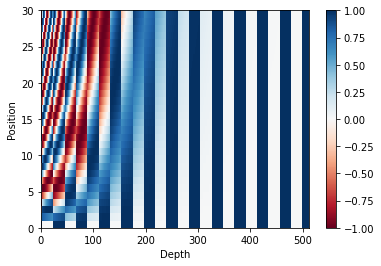

In [23]:
plt.pcolormesh(pos_encoding[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

## 3. 遮挡

In [24]:
def create_padding_mask(seq):
    # 将 seq 序列中为 0 的位置标记为 1，其它的位置标记为 0
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return seq[:, tf.newaxis, tf.newaxis, :]

x = tf.constant([[7, 6, 0, 0, 1], [1, 2, 3, 0, 0], [0, 0, 0, 4, 5]])
create_padding_mask(x)

<tf.Tensor: shape=(3, 1, 1, 5), dtype=float32, numpy=
array([[[[0., 0., 1., 1., 0.]]],


       [[[0., 0., 0., 1., 1.]]],


       [[[1., 1., 1., 0., 0.]]]], dtype=float32)>

In [25]:
def create_look_ahead_mask(size):
    # 以对角线为中心，取指定带宽的上三角和下三角，其它数据 0 填充
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask


x = tf.random.uniform((1, 3))
print(create_look_ahead_mask(x.shape[1]))

tf.Tensor(
[[0. 1. 1.]
 [0. 0. 1.]
 [0. 0. 0.]], shape=(3, 3), dtype=float32)


## 4. 注意力计算

In [26]:
def scaled_dot_product_attention(q, k, v, mask):
    
    matmul_qk = tf.matmul(q, k, transpose_b=True)

    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
    
    if mask is not None:
        scaled_attention_logits += (mask * -1e9)
        # 在待遮挡处减去一个较大值，softmax 即可忽略该位置

    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)

    output = tf.matmul(attention_weights, v)

    return output, attention_weights

In [27]:
def print_out(q, k, v):
    # 创建一个与 q * k 形状相同的 mask
    mask = tf.matmul(q, k, transpose_b=True)
    temp_out, temp_attn = scaled_dot_product_attention(q, k, v, mask)
    print('Attention weights are:')
    print(temp_attn)
    print('Output is:')
    print(temp_out)

In [28]:
np.set_printoptions(suppress=True)

temp_k = tf.constant([[10, 0, 0], [0, 10, 0], [0, 0, 10], [0, 0, 10]],
                     dtype=tf.float32)  # (4, 3)

temp_v = tf.constant([[1, 0], [10, 0], [100, 5], [1000, 6]],
                     dtype=tf.float32) 

temp_q = tf.constant([[0, 10, 0]], dtype=tf.float32)  
print_out(temp_q, temp_k, temp_v)

Attention weights are:
tf.Tensor([[0.33333334 0.         0.33333334 0.33333334]], shape=(1, 4), dtype=float32)
Output is:
tf.Tensor([[366.9104      3.6657715]], shape=(1, 2), dtype=float32)


2024-07-14 17:31:50.507862: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


## 5. 多头注意力层

In [29]:
class MultiHeadAttention(tf.keras.layers.Layer):
    # 初始化函数，接收模型的维度 d_model 和头数 num_heads
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # 确保 d_model 可以被 num_heads 整除
        assert self.d_model % self.num_heads == 0

        # 计算每个头处理的特征维度
        self.depth = d_model // self.num_heads

        # 定义查询（q）、键（k）和值（v）的线性变换层
        self.wq = tf.keras.layers.Dense(self.d_model)
        self.wk = tf.keras.layers.Dense(self.d_model)
        self.wv = tf.keras.layers.Dense(self.d_model)

        # 定义最终输出的线性变换层
        self.dense = tf.keras.layers.Dense(d_model)

    # 将输入张量分割成多个头
    def split_heads(self, x, batch_size):
        # 将输入张量重新排列并分割成 num_heads 个头
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        # 交换维度，使得头的维度在第二位
        return tf.transpose(x, perm=(0, 2, 1, 3))

    # 调用函数，执行多头注意力机制
    def call(self, v, k, q, mask):
        # 获取批次大小
        batch_size = tf.shape(q)[0]

        # 对查询、键和值进行线性变换
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)

        # 分割查询、键和值到不同的头
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # 计算缩放点积注意力和注意力权重
        scaled_attention, attention_weights = scaled_dot_product_attention(
            q, k, v, mask)

        # 将缩放后的注意力结果重新排列
        scaled_attention = tf.transpose(
            scaled_attention,
            perm=[0, 2, 1, 3])  
        # 将排列后的注意力结果重新拼接成原始批次大小的三维张量
        concat_attention = tf.reshape(scaled_attention,
                                      (batch_size, -1, self.d_model))

        # 通过最终的线性变换层输出结果
        output = self.dense(
            concat_attention)
        # 返回输出和注意力权重
        return output, attention_weights

In [30]:
temp_mha = MultiHeadAttention(d_model=512, num_heads=8)
y = tf.random.uniform((1, 60, 512))
out, attn = temp_mha(y, k=y, q=y, mask=None)

## 6. 前馈网络

In [31]:
def point_wise_feed_forward_network(d_model, dff):
    # 使用Sequential模型来创建一个线性堆叠的模型
    return tf.keras.Sequential([
        # 第一个全连接层，使用ReLU激活函数
        tf.keras.layers.Dense(dff, activation='relu'),
        # 第二个全连接层，输出维度与输入维度相同
        tf.keras.layers.Dense(d_model)
    ])

# 调用函数，创建一个具有特定维度的点式前馈网络
sample_ffn = point_wise_feed_forward_network(512, 2048)

# 使用创建的前馈网络处理一个随机生成的三维张量
# 假设批次大小为64，序列长度为50，特征维度为512
sample_output = sample_ffn(tf.random.uniform((64, 50, 512)))

# 打印输出张量的形状，以确认网络输出的维度
print(sample_output.shape)

(64, 50, 512)


## 7. 编码与解码


#### 7.1 编码器层

In [32]:
class EncoderLayer(tf.keras.layers.Layer):
    # 初始化函数，用于创建编码器层
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(EncoderLayer, self).__init__()

        # 创建多头注意力机制的层实例
        self.mha = MultiHeadAttention(d_model, num_heads)
        # 创建点式前馈网络的层实例
        self.ffn = point_wise_feed_forward_network(d_model, dff)

        # 创建两个层归一化（Layer Normalization）层
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        # 创建两个Dropout层以进行正则化，防止过拟合
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    # 调用函数，执行编码器层的前向传播
    def call(self, x, training, mask):
        # 执行多头注意力机制，并将结果与原始输入相加
        attn_output, _ = self.mha(x, x, x, mask)
        # 应用Dropout层并根据训练状态决定是否应用dropout
        attn_output = self.dropout1(attn_output, training=training)
        # 将多头注意力的输出与原始输入相加，并通过第一层归一化层
        out1 = self.layernorm1(x + attn_output)

        # 将归一化后的输出传递给前馈网络
        ffn_output = self.ffn(out1)
        # 应用第二个Dropout层
        ffn_output = self.dropout2(ffn_output, training=training)
        # 将前馈网络的输出与经过归一化和注意力机制处理的输出相加，并通过第二层归一化层
        out2 = self.layernorm2(out1 + ffn_output)

        # 返回编码器层的最终输出
        return out2

In [33]:
sample_encoder_layer = EncoderLayer(512, 8, 2048)

sample_encoder_layer_output = sample_encoder_layer(
    tf.random.uniform((64, 43, 512)), False, None)

#### 7.2 解码器层

In [34]:
class DecoderLayer(tf.keras.layers.Layer):
    # 初始化函数，用于创建解码器层
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(DecoderLayer, self).__init__()

        # 创建两个多头注意力机制的层实例，一个用于遮蔽自身，一个用于编码器-解码器交互
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        
        # 创建点式前馈网络的层实例
        self.ffn = point_wise_feed_forward_network(d_model, dff)
        
        # 创建三个层归一化（Layer Normalization）层
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        
        # 创建三个Dropout层以进行正则化，防止过拟合
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)
        self.dropout3 = tf.keras.layers.Dropout(rate)

    # 调用函数，执行解码器层的前向传播
    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        # 第一个多头注意力机制，只使用解码器的输入，应用遮蔽以防止未来的信息流入
        attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask)
        # 应用Dropout层
        attn1 = self.dropout1(attn1, training=training)
        # 残差连接后通过第一层归一化层
        out1 = self.layernorm1(attn1 + x)

        # 第二个多头注意力机制，使用编码器的输出和第一个注意力机制的输出
        attn2, attn_weights_block2 = self.mha2(enc_output, enc_output, out1, padding_mask)
        # 应用Dropout层
        attn2 = self.dropout2(attn2, training=training)
        # 残差连接后通过第二层归一化层
        out2 = self.layernorm2(attn2 + out1)

        # 将归一化后的输出传递给前馈网络
        ffn_output = self.ffn(out2)
        # 应用第三个Dropout层
        ffn_output = self.dropout3(ffn_output, training=training)
        # 残差连接后通过第三层归一化层
        out3 = self.layernorm3(ffn_output + out2) 

        # 返回解码器层的最终输出以及两个注意力机制的权重
        return out3, attn_weights_block1, attn_weights_block2

In [35]:
sample_decoder_layer = DecoderLayer(512, 8, 2048)

sample_decoder_layer_output, _, _ = sample_decoder_layer(
    tf.random.uniform((64, 50, 512)), sample_encoder_layer_output, False, None,
    None)

#### 7.3 编码器

In [36]:
class Encoder(tf.keras.layers.Layer):
    # 初始化函数，用于创建编码器
    def __init__(self,
                 num_layers,
                 d_model,
                 num_heads,
                 dff,
                 input_vocab_size,
                 maximum_position_encoding,
                 rate=0.1):
        super(Encoder, self).__init__()

        # 模型的特征维度
        self.d_model = d_model
        # 编码器层的数量
        self.num_layers = num_layers

        # 创建词汇表大小为input_vocab_size，特征维度为d_model的嵌入层
        self.embedding = tf.keras.layers.Embedding(input_vocab_size, d_model)
        # 创建位置编码，用于提供序列中单词的位置信息
        self.pos_encoding = positional_encoding(maximum_position_encoding, self.d_model)

        # 创建num_layers个编码器层的列表
        self.enc_layers = [
            EncoderLayer(d_model, num_heads, dff, rate)
            for _ in range(num_layers)
        ]
        # 创建Dropout层以进行正则化，防止过拟合
        self.dropout = tf.keras.layers.Dropout(rate)

    # 调用函数，执行编码器的前向传播
    def call(self, x, training, mask):
        # 获取序列长度
        seq_len = tf.shape(x)[1]

        # 将输入x通过嵌入层转换为连续的词向量
        x = self.embedding(x)
        # 缩放词向量以避免梯度消失问题
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        # 将位置编码加到词向量上，提供位置信息
        x += self.pos_encoding[:, :seq_len, :]

        # 应用Dropout层
        x = self.dropout(x, training=training)

        # 遍历编码器层列表，逐层处理输入x
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training, mask)

        # 返回编码器的输出
        return x

In [37]:
sample_encoder = Encoder(num_layers=2,
                         d_model=512,
                         num_heads=8,
                         dff=2048,
                         input_vocab_size=8500,
                         maximum_position_encoding=10000)

sample_encoder_output = sample_encoder(tf.random.uniform((64, 62)),
                                       training=False,
                                       mask=None)

#### 7.4 解码器

In [38]:
class Decoder(tf.keras.layers.Layer):
    # 初始化函数，用于创建解码器
    def __init__(self,
                 num_layers,
                 d_model,
                 num_heads,
                 dff,
                 target_vocab_size,
                 maximum_position_encoding,
                 rate=0.1):
        super(Decoder, self).__init__()

        # 模型的特征维度
        self.d_model = d_model
        # 解码器层的数量
        self.num_layers = num_layers

        # 创建目标词汇表大小为target_vocab_size，特征维度为d_model的嵌入层
        self.embedding = tf.keras.layers.Embedding(target_vocab_size, d_model)
        # 创建位置编码，用于提供序列中单词的位置信息
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)

        # 创建num_layers个解码器层的列表
        self.dec_layers = [
            DecoderLayer(d_model, num_heads, dff, rate)
            for _ in range(num_layers)
        ]
        # 创建Dropout层以进行正则化，防止过拟合
        self.dropout = tf.keras.layers.Dropout(rate)

    # 调用函数，执行解码器的前向传播
    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        # 获取序列长度
        seq_len = tf.shape(x)[1]
        # 初始化一个字典来存储每层解码器的注意力权重
        attention_weights = {}

        # 将输入x通过嵌入层转换为连续的词向量
        x = self.embedding(x)
        # 缩放词向量以避免梯度消失问题
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        # 将位置编码加到词向量上，提供位置信息
        x += self.pos_encoding[:, :seq_len, :]

        # 应用Dropout层
        x = self.dropout(x, training=training)

        # 遍历解码器层列表，逐层处理输入x
        for i in range(self.num_layers):
            # 对每层解码器执行操作，同时获取当前层的两个注意力权重
            x, block1, block2 = self.dec_layers[i](x, enc_output, training,
                                                   look_ahead_mask,
                                                   padding_mask)
            # 将当前层的两个注意力权重存储到字典中
            attention_weights['decoder_layer{}_block1'.format(i + 1)] = block1
            attention_weights['decoder_layer{}_block2'.format(i + 1)] = block2

        # 返回解码器的输出和所有层的注意力权重
        return x, attention_weights

In [39]:
sample_decoder = Decoder(num_layers=2, d_model=512, num_heads=8, dff=2048,
                         target_vocab_size=8000, maximum_position_encoding=5000)

output, attn = sample_decoder(tf.random.uniform((64, 26)),
                              enc_output=sample_encoder_output, training=False,
                              look_ahead_mask=None, padding_mask=None)

## 8. Transformer


In [40]:
class Transformer(tf.keras.Model):
    # 初始化函数，用于创建Transformer模型
    def __init__(self,
                 num_layers,
                 d_model,
                 num_heads,
                 dff,
                 input_vocab_size,
                 target_vocab_size,
                 pe_input,
                 pe_target,
                 rate=0.1):
        super(Transformer, self).__init__()

        # 创建编码器实例
        self.encoder = Encoder(num_layers, d_model, num_heads, dff,
                               input_vocab_size, pe_input, rate)
        # 创建解码器实例
        self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                               target_vocab_size, pe_target, rate)
        # 创建输出层，用于在解码器输出上进行词汇表大小的全连接操作
        self.final_layer = tf.keras.layers.Dense(target_vocab_size)

    # 调用函数，执行Transformer模型的前向传播
    def call(self, inp, tar, training, enc_padding_mask, look_ahead_mask,
             dec_padding_mask):
        # 通过编码器处理输入序列inp
        enc_output = self.encoder(inp, training, enc_padding_mask)
        
        # 通过解码器处理编码器的输出和目标序列tar
        # 注意：这里的tar应该是解码器的初始输入，通常是包含特殊开始标记的序列
        dec_output, attention_weights = self.decoder(tar, enc_output, training,
                                                    look_ahead_mask,
                                                    dec_padding_mask)
        
        # 将解码器的输出通过最终的全连接层来生成最终的预测结果
        final_output = self.final_layer(dec_output)
        
        # 返回模型的最终输出和解码器的注意力权重
        return final_output, attention_weights

In [41]:
# 创建一个Transformer模型实例
sample_transformer = Transformer(
    # 编码器和解码器的层数
    num_layers=2,
    # 模型的特征维度
    d_model=512,
    # 多头注意力机制中的头数
    num_heads=8,
    # 前馈网络的维度
    dff=2048,
    # 输入词汇表的大小
    input_vocab_size=8500,
    # 目标词汇表的大小
    target_vocab_size=8000,
    # 编码器位置编码的最大长度
    pe_input=10000,
    # 解码器位置编码的最大长度
    pe_target=6000
)

temp_input = tf.random.uniform((64, 62))
temp_target = tf.random.uniform((64, 26))

# 使用Transformer模型进行前向传播
# fn_out 将存储模型的最终输出
# attention_weights 存储解码器的注意力权重，这里未使用，所以用 _ 忽略
fn_out, _ = sample_transformer(
    temp_input,               # 输入序列
    temp_target,              # 目标序列
    training=False,           # 指示当前是否处于训练状态，False 表示推理状态
    enc_padding_mask=None,    # 编码器的填充掩码，这里没有提供
    look_ahead_mask=None,     # 解码器的遮蔽掩码，这里没有提供
    dec_padding_mask=None     # 解码器的填充掩码，这里没有提供
)

## 9. 参数配置

In [42]:
num_layers = 4
d_model = 128
dff = 512
num_heads = 8

input_vocab_size = len(zh_tokenizer.word_index) + 1
target_vocab_size = len(eng_tokenizer.word_index) + 1
dropout_rate = 0.1

## 10. 优化器

In [43]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    # 初始化函数，用于创建自定义学习率调度
    def __init__(self, d_model, warmup_steps=4000):
        super(CustomSchedule, self).__init__()

        # 模型的特征维度，用于计算学习率的一部分
        self.d_model = d_model
        # 将d_model转换为浮点数
        self.d_model = tf.cast(self.d_model, tf.float32)
        # 预热步数，用于在训练初期逐渐增加学习率
        self.warmup_steps = warmup_steps

    # 调用函数，根据当前步数计算学习率
    def __call__(self, step):
        # 第一个参数：使用逐步的平方根递减策略
        arg1 = tf.math.rsqrt(step)
        # 第二个参数：预热策略，随着步数增加，学习率按一定速率增加
        arg2 = step * (self.warmup_steps**-1.5)

        # 计算最终的学习率，为模型特征维度的平方根与上述两个参数中较小者
        # 的乘积。这结合了预热策略和逐步降低学习率的策略
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

In [44]:
learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate,
                                     beta_1=0.9,
                                     beta_2=0.98,
                                     epsilon=1e-9)

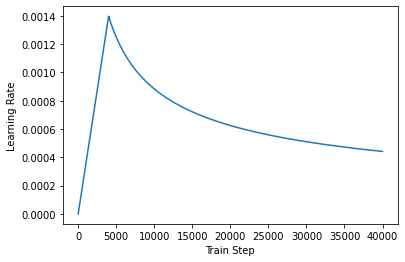

In [45]:
temp_learning_rate_schedule = CustomSchedule(d_model)

plt.plot(temp_learning_rate_schedule(tf.range(40000, dtype=tf.float32)))
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")
plt.show()

## 11. 损失函数

In [46]:
# 损失函数是SparseCategoricalCrossentropy，它适用于多类分类问题
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

# 定义自定义损失函数，计算预测值pred和真实值real之间的损失
def loss_function(real, pred):
    # 计算mask，用于屏蔽掉真实标签为0的项，即忽略填充项
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    
    # 计算原始损失
    loss_ = loss_object(real, pred)
    
    # 将mask转换为与损失相同的数据类型
    mask = tf.cast(mask, dtype=loss_.dtype)
    
    # 应用mask，忽略mask为False的损失项
    loss_ *= mask
    
    # 返回平均损失，通过对mask为True的损失项求和后除以mask为True的总数
    return tf.reduce_mean(loss_)

## 12. 训练

In [47]:
# 初始化Transformer模型，传入相应的参数
transformer = Transformer(
    num_layers,         
    d_model,             
    num_heads,          
    dff,                 
    input_vocab_size,    
    target_vocab_size,  
    pe_input=input_vocab_size,  
    pe_target=target_vocab_size,  
    rate=dropout_rate    
)

# 定义创建掩码的函数，这些掩码将用于Transformer模型的编码器和解码器
def create_masks(inp, tar):

    enc_padding_mask = create_padding_mask(inp)
    
    dec_padding_mask = create_padding_mask(inp)

    look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])

    dec_target_padding_mask = create_padding_mask(tar)

    combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)
    
    return enc_padding_mask, combined_mask, dec_padding_mask

# 设置检查点保存路径
checkpoint_path = "../H/save/zh2eng_transformer"

# 创建检查点，包含Transformer模型和优化器状态
ckpt = tf.train.Checkpoint(transformer=transformer, optimizer=optimizer)

# 创建检查点管理器，管理检查点的保存和恢复
# max_to_keep=5表示最多只保存5个检查点文件
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

# 如果存在最新的检查点，则恢复该检查点
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    print('Latest checkpoint restored!!')

In [48]:
EPOCHS = 80

# 初始化列表来记录每个 epoch 的训练和测试 loss 和 accuracy
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# 定义训练和验证的指标
train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
val_loss = tf.keras.metrics.Mean(name='val_loss')
val_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')

@tf.function()
def train_step(inp, tar):
    tar_inp = tar[:, :-1]
    tar_real = tar[:, 1:]   # 给定前面的词，预测下一个词

    enc_padding_mask, combined_mask, dec_padding_mask = create_masks(inp, tar_inp)

    with tf.GradientTape() as tape:
        predictions, _ = transformer(inp, tar_inp, True, enc_padding_mask, combined_mask, dec_padding_mask)
        loss = loss_function(tar_real, predictions)

    gradients = tape.gradient(loss, transformer.trainable_variables)
    optimizer.apply_gradients(zip(gradients, transformer.trainable_variables))

    train_loss(loss)
    train_accuracy(tar_real, predictions)

@tf.function()
def val_step(inp, tar):
    tar_inp = tar[:, :-1]
    tar_real = tar[:, 1:]

    enc_padding_mask, combined_mask, dec_padding_mask = create_masks(inp, tar_inp)

    predictions, _ = transformer(inp, tar_inp, False, enc_padding_mask, combined_mask, dec_padding_mask)
    loss = loss_function(tar_real, predictions)

    val_loss(loss)
    val_accuracy(tar_real, predictions)

In [49]:
for epoch in range(EPOCHS):
    start = time.time()

    train_accuracy.reset_states()
    val_accuracy.reset_states()

    # 初始化变量记录每个 epoch 的总 loss 和 accuracy
    total_train_loss = 0
    total_train_accuracy = 0
    num_train_batches = 0

    for (batch, (inp, tar)) in enumerate(dataset):
        train_step(inp, tar)

        total_train_loss += train_loss.result().numpy()
        total_train_accuracy += train_accuracy.result().numpy()
        num_train_batches += 1

    # 计算每个 epoch 的平均 train loss 和 accuracy
    avg_train_loss = total_train_loss / num_train_batches
    avg_train_accuracy = total_train_accuracy / num_train_batches

    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_accuracy)

    # 在测试集上计算 loss 和 accuracy
    total_val_loss = 0
    total_val_accuracy = 0
    num_val_batches = 0

    for (batch, (inp, tar)) in enumerate(dataset_val):
        val_step(inp, tar)

        total_val_loss += val_loss.result().numpy()
        total_val_accuracy += val_accuracy.result().numpy()
        num_val_batches += 1

    avg_val_loss = total_val_loss / num_val_batches
    avg_val_accuracy = total_val_accuracy / num_val_batches
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_accuracy)

    if (epoch + 1) % 5 == 0:
        ckpt_save_path = ckpt_manager.save()
        print('Saving checkpoint for epoch {} at {}'.format(
            epoch + 1, ckpt_save_path))

    print('Epoch {} Loss {:.4f} Accuracy {:.4f} Val_Loss {:.4f} Val_Accuracy {:.4f}'.format(
        epoch + 1, avg_train_loss, avg_train_accuracy, avg_val_loss, avg_val_accuracy))

    print('Time taken for 1 epoch: {} secs\n'.format(time.time() - start))

Epoch 1 Loss 1.9712 Accuracy 0.0694 Val_Loss 1.4490 Val_Accuracy 0.2358
Time taken for 1 epoch: 17.98222041130066 secs

Epoch 2 Loss 1.6538 Accuracy 0.2049 Val_Loss 1.3350 Val_Accuracy 0.3900
Time taken for 1 epoch: 8.550358533859253 secs

Epoch 3 Loss 1.4262 Accuracy 0.3185 Val_Loss 1.1946 Val_Accuracy 0.4681
Time taken for 1 epoch: 8.607723474502563 secs

Epoch 4 Loss 1.2747 Accuracy 0.3779 Val_Loss 1.0921 Val_Accuracy 0.5419
Time taken for 1 epoch: 8.333224773406982 secs

Saving checkpoint for epoch 5 at ../H/save/zh2eng_transformer/ckpt-1
Epoch 5 Loss 1.1621 Accuracy 0.4355 Val_Loss 1.0106 Val_Accuracy 0.6276
Time taken for 1 epoch: 9.079511642456055 secs

Epoch 6 Loss 1.0702 Accuracy 0.5068 Val_Loss 0.9421 Val_Accuracy 0.6983
Time taken for 1 epoch: 8.668086767196655 secs

Epoch 7 Loss 0.9928 Accuracy 0.5619 Val_Loss 0.8850 Val_Accuracy 0.7299
Time taken for 1 epoch: 8.702958345413208 secs

Epoch 8 Loss 0.9268 Accuracy 0.5923 Val_Loss 0.8376 Val_Accuracy 0.7608
Time taken for 1 ep

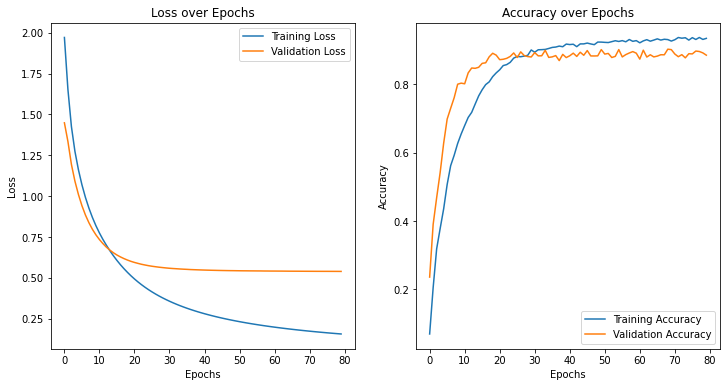

In [50]:
# 绘制 loss 和 accuracy 的图表
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), train_losses, label='Training Loss')
plt.plot(range(EPOCHS), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), train_accuracies, label='Training Accuracy')
plt.plot(range(EPOCHS), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()

## 13. 翻译及可视化

In [56]:
max_length_ch = zh_tensor.shape[-1]
max_length_eng = eng_tensor.shape[-1]


def evaluate(inp_sentence):
    sentence = preprocess_zh(inp_sentence)
    inputs = [zh_tokenizer.word_index[i] for i in sentence.split(' ')]
    inputs = tf.keras.preprocessing.sequence.pad_sequences(
        [inputs], maxlen=max_length_ch, padding='post')
    encoder_input = tf.convert_to_tensor(inputs)


    # 因为目标是英语，输入 transformer 的第一个词应该是
    # 英语的开始标记。
    decoder_input = [eng_tokenizer.word_index['<start>']]
    output = tf.expand_dims(decoder_input, 0)

    for i in range(max_length_eng):
        enc_padding_mask, combined_mask, dec_padding_mask = create_masks(
            encoder_input, output)

        # predictions.shape == (batch_size, seq_len, vocab_size)
        predictions, attention_weights = transformer(encoder_input, output,
                                                     False, enc_padding_mask,
                                                     combined_mask,
                                                     dec_padding_mask)

        # 从 seq_len 维度选择最后一个词
        predictions = predictions[:, -1:, :]  # (batch_size, 1, vocab_size)

        predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)

        # 如果 predicted_id 等于结束标记，就返回结果
        if predicted_id == eng_tokenizer.word_index['<end>']:
            return tf.squeeze(output, axis=0), attention_weights

        # 连接 predicted_id 与输出，作为解码器的输入传递到解码器。
        output = tf.concat([output, predicted_id], axis=-1)

    return tf.squeeze(output, axis=0), attention_weights

In [81]:
# 选择字体
my_font = FontProperties(fname="SIMHEI.TTF")

def plot_attention_weights(attention, sentence, result, layer):
    print(result)

    fig = plt.figure(figsize=(20, 10))  # 调整整体图形大小

    # 预处理中文句子，并将其转化为索引
    sentence = preprocess_zh(sentence)
    sentence_tokens = [zh_tokenizer.word_index[i] for i in sentence.split(' ')]

    attention = tf.squeeze(attention[layer], axis=0)

    for head in range(attention.shape[0]):
        ax = fig.add_subplot(2, 4, head + 1)  # 将图形设置为4行2列的子图

        # 画出注意力权重
        ax.matshow(attention[head][:, :-1], cmap='viridis')

        fontdict = {'fontsize': 14, 'fontproperties': my_font}  # 调整字体大小为14

        # 设置 xticks 和 yticks
        ax.set_xticks(range(len(sentence_tokens) + 1))  # +1 是为了包括 <end> 标记
        ax.set_yticks(range(len(result) + 1))  # +1 是为了包括 <end> 标记

        ax.set_ylim(len(result) - 0.5, -0.5)  # 修正 ylim 设置
        ax.set_xlim(-0.5, len(sentence_tokens) + 0.5)  # 修正 xlim 设置

        # 设置 xticklabels 和 yticklabels
        ax.set_xticklabels(
            [zh_tokenizer.index_word[i] for i in sentence_tokens] + ['<end>'],
            fontproperties=my_font,  # 使用字体属性设置
            rotation=90)  # 可选：旋转标签以适应空间
        ax.set_yticklabels(
            [eng_tokenizer.index_word[i.numpy()] for i in result] + ['<end>'],
            fontproperties=my_font,  # 使用字体属性设置
            rotation=0)  # 不旋转英文标签

        ax.set_xlabel('Head {}'.format(head + 1), fontproperties=my_font)  # 设置 x 轴标签字体

    plt.tight_layout()
    plt.savefig('hot')
    plt.show()


In [82]:
def translate(sentence, plot=''):
    result, attention_weights = evaluate(sentence)

    predicted_sentence = ' '.join(
        [eng_tokenizer.index_word[i] for i in result.numpy()[1:]])

    print('Input: {}'.format(sentence))
    print('Predicted translation: {}'.format(predicted_sentence))

    if plot:
        plot_attention_weights(attention_weights, sentence, result, plot)

Input: 城市化进程带动了大量农民工进入城市就业市场。
Predicted translation: the urbanization process has led to a large influx of migrant workers into urban employment markets .
tf.Tensor(
[   1    4  575  425   39 1399    6    8  479 1400   12 1401 1041  195
  271 1258 1402    3], shape=(18,), dtype=int32)


<Figure size 432x288 with 0 Axes>

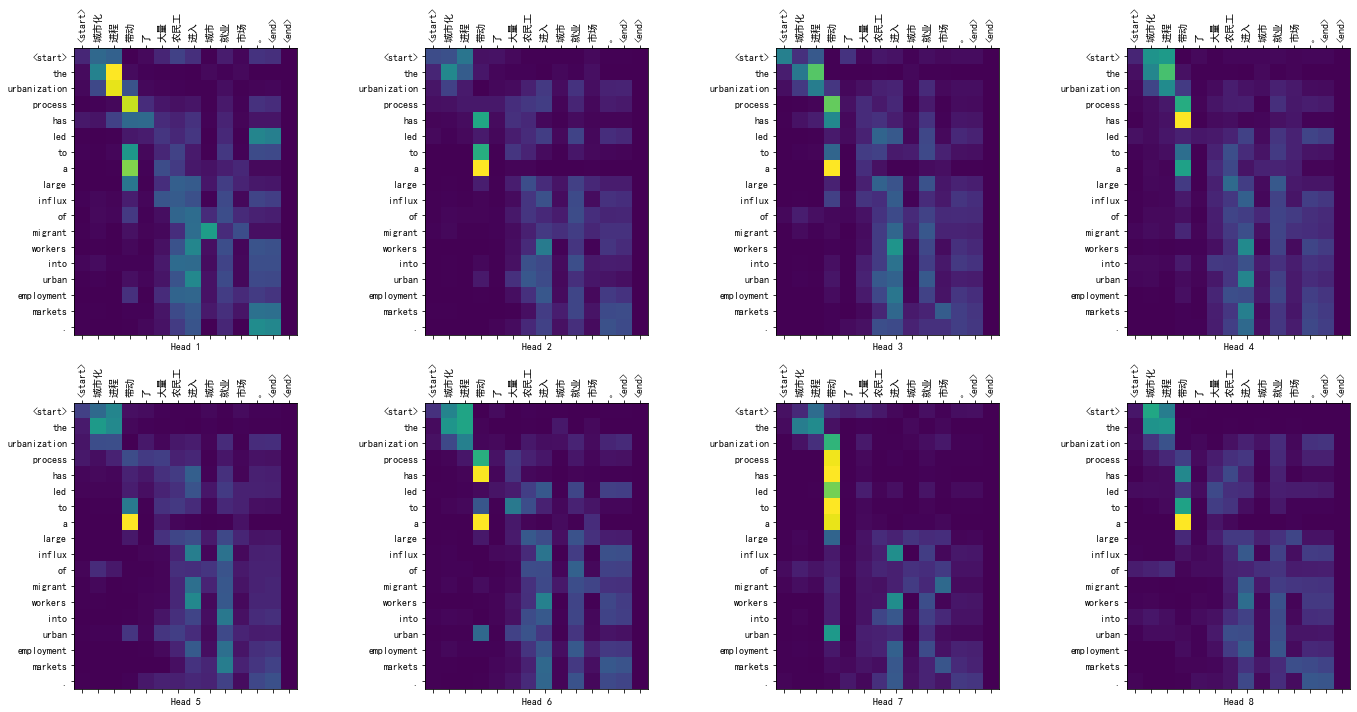

In [85]:
translate("城市化进程带动了大量农民工进入城市就业市场。", plot='decoder_layer4_block2')